Best Params: {'max_depth': 5, 'min_samples_leaf': 1}
Mean CV Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

        High       0.88      0.78      0.82        36
         Low       0.93      0.83      0.88        47
      Medium       0.84      1.00      0.91        46

    accuracy                           0.88       129
   macro avg       0.88      0.87      0.87       129
weighted avg       0.88      0.88      0.87       129

Confusion Matrix:
 [[28  5  3]
 [ 0 46  0]
 [ 4  4 39]]


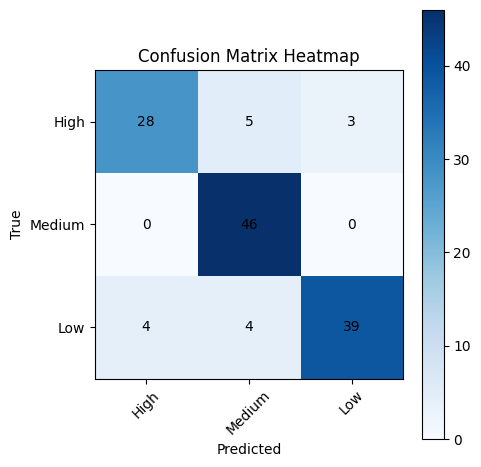

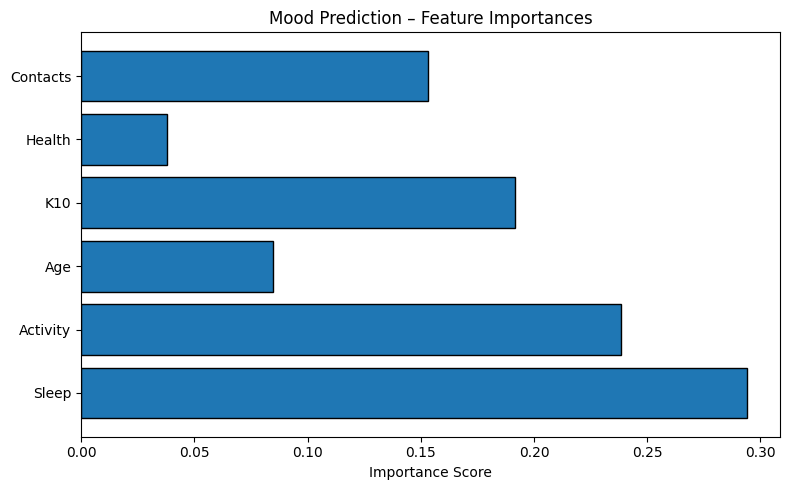

In [7]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import matplotlib.pyplot as plt

# 1. Generate mock ABS-style data with six inputs
np.random.seed(42)
data = pd.DataFrame({
    'Sleep': np.random.uniform(4, 9, size=300),        # Hours per night
    'Activity': np.random.uniform(0, 7, size=300),     # Exercise hours per week
    'Age': np.random.randint(18, 65, size=300),        # Age in years
    'K10': np.random.randint(10, 50, size=300),        # Distress score (10–50)
    'Health': np.random.randint(1, 6, size=300),       # Self-rated health (1–5)
    'Contacts': np.random.randint(0, 10, size=300)     # Weekly close contacts
})

# 2. Define rule-based mood function
def predict_mood_rule(row):
    if row['Sleep'] <= 5 and row['K10'] >= 35:
        return 'Low'    # Extreme distress + poor sleep
    if (row['Sleep'] >= 7 or row['Activity'] >= 5) and row['Contacts'] >= 3:
        return 'High'   # Good sleep/exercise + social support
    return None        # Others defer to regression

# 3. Compute continuous MoodScore via regression formula
def compute_mood_score(row):
    S, A = row['Sleep'], row['Activity']
    D, K = row['Age']/10, row['K10']/10
    H, C = row['Health'], row['Contacts']
    return 0.25*S + 0.20*A - 0.15*D - 0.30*K + 0.10*H + 0.10*C + 2.0

# 4. Combine rule-based and regression thresholds
def predict_mood(row):
    label = predict_mood_rule(row)
    if label:
        return label
    score = compute_mood_score(row)
    if score >= 7:
        return 'High'
    if score <= 4:
        return 'Low'
    return 'Medium'

# 5. Label data
data['Mood'] = data.apply(predict_mood, axis=1)

# 6. Balance 'Medium' class via oversampling
major = data[data['Mood'] != 'Medium']
med = data[data['Mood'] == 'Medium']
med_up = resample(med, replace=True, n_samples=major['Mood'].value_counts().max(), random_state=42)
balanced = pd.concat([major, med_up])

# 7. Prepare features and labels
features = ['Sleep', 'Activity', 'Age', 'K10', 'Health', 'Contacts']
X = balanced[features]
y = balanced['Mood']

# 8. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 9. Hyperparameter tuning for Decision Tree
param_grid = {'max_depth': [3, 4, 5], 'min_samples_leaf': [1, 5, 10]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)
best_clf = grid.best_estimator_

# 10. Cross-validation performance
cv_scores = cross_val_score(best_clf, X_train, y_train, cv=5)
print(f"Best Params: {grid.best_params_}")
print(f"Mean CV Accuracy: {cv_scores.mean():.2f}\n")

# 11. Evaluate on the test set
y_pred = best_clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=['High', 'Medium', 'Low'])
print("Confusion Matrix:\n", cm)

# 12. Plot confusion matrix heatmap
plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix Heatmap')
plt.colorbar()
# Define class labels
cls = ['High', 'Medium', 'Low']
ticks = np.arange(len(cls))
plt.xticks(ticks, cls, rotation=45)
plt.yticks(ticks, cls)
# Add text inside squares
for i in range(len(cls)):
    for j in range(len(cls)):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# 13. Plot feature importances
importances = best_clf.feature_importances_
plt.figure(figsize=(8, 5))
plt.barh(features, importances, edgecolor='black')
plt.title('Mood Prediction – Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# End of model implementation
